In [1]:
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
from typing import TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
class ReportState(TypedDict):
    title:str
    outline:str
    report:str
    summary:str

In [4]:
graph = StateGraph(ReportState)

In [5]:
def outlineGen(state:ReportState):
    title = state["title"]
    prompt = f"Generate a outline for writing report on this title {title}"
    outline = model.invoke(prompt).content 
    state["outline"] = outline 
    return {"outline":outline}
def reportGen(state:ReportState):
    title = state["title"]
    outline = state["outline"]
    prompt = f"Generate a report for writing reportwith this title and outline title: {title} \n outline:{outline} "
    report = model.invoke(prompt).content 
    state["report"] = report 
    return {"report":report}

def summaryGen(state:ReportState):
    report = state["report"]
    prompt = f"Generate a summary of this report : \n {report}"
    summary = model.invoke(prompt).content 
    state["summary"] = summary 
    return {"summary":summary}


In [6]:
graph.add_node("generateOutline",outlineGen)
graph.add_node("generateReport",reportGen)
graph.add_node("generateSummary",summaryGen)

In [7]:
graph.add_edge(START,"generateOutline")
graph.add_edge("generateOutline","generateReport")
graph.add_edge("generateReport","generateSummary")
graph.add_edge("generateSummary",END)


In [8]:
workflow = graph.compile()

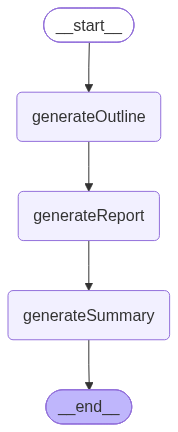

In [9]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())

In [10]:
results = workflow.invoke({"title":"Becoming top 1 percent sofwate developer"})
print(results["outline"])
print(results["report"])
print(results["summary"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Here's a comprehensive outline for a report titled "Becoming a Top 1% Software Developer," designed to be thorough, actionable, and inspiring.

---

**Report Outline: Becoming a Top 1% Software Developer**

**I. Title Page**
    *   Report Title: Becoming a Top 1% Software Developer
    *   Author(s): [Your Name/Team Name]
    *   Date: [Current Date]

**II. Table of Contents**
    *   (Auto-generated based on the outline below)

**III. Executive Summary (Abstract)**
    *   Brief overview of what "top 1%" means in software development.
    *   Summary of key pillars and strategies discussed in the report (e.g., technical mastery, soft skills, continuous learning, impact).
    *   Statement of the report's purpose: to provide a roadmap for aspiring and current developers.

**IV. Introduction**
    *   **A. The Pursuit of Excellence:**
        *   The competitive landscape of software development.
        *   The increasing demand for truly exceptional talent.
        *   Why strive for